# **Assignment 14: Principal Component Analysis (PCA) & Clustering Analysis**

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

**Task 1: Exploratory Data Analysis (EDA)**

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None

--- Summary Statistics ---
             Type     Alcohol       Malic     

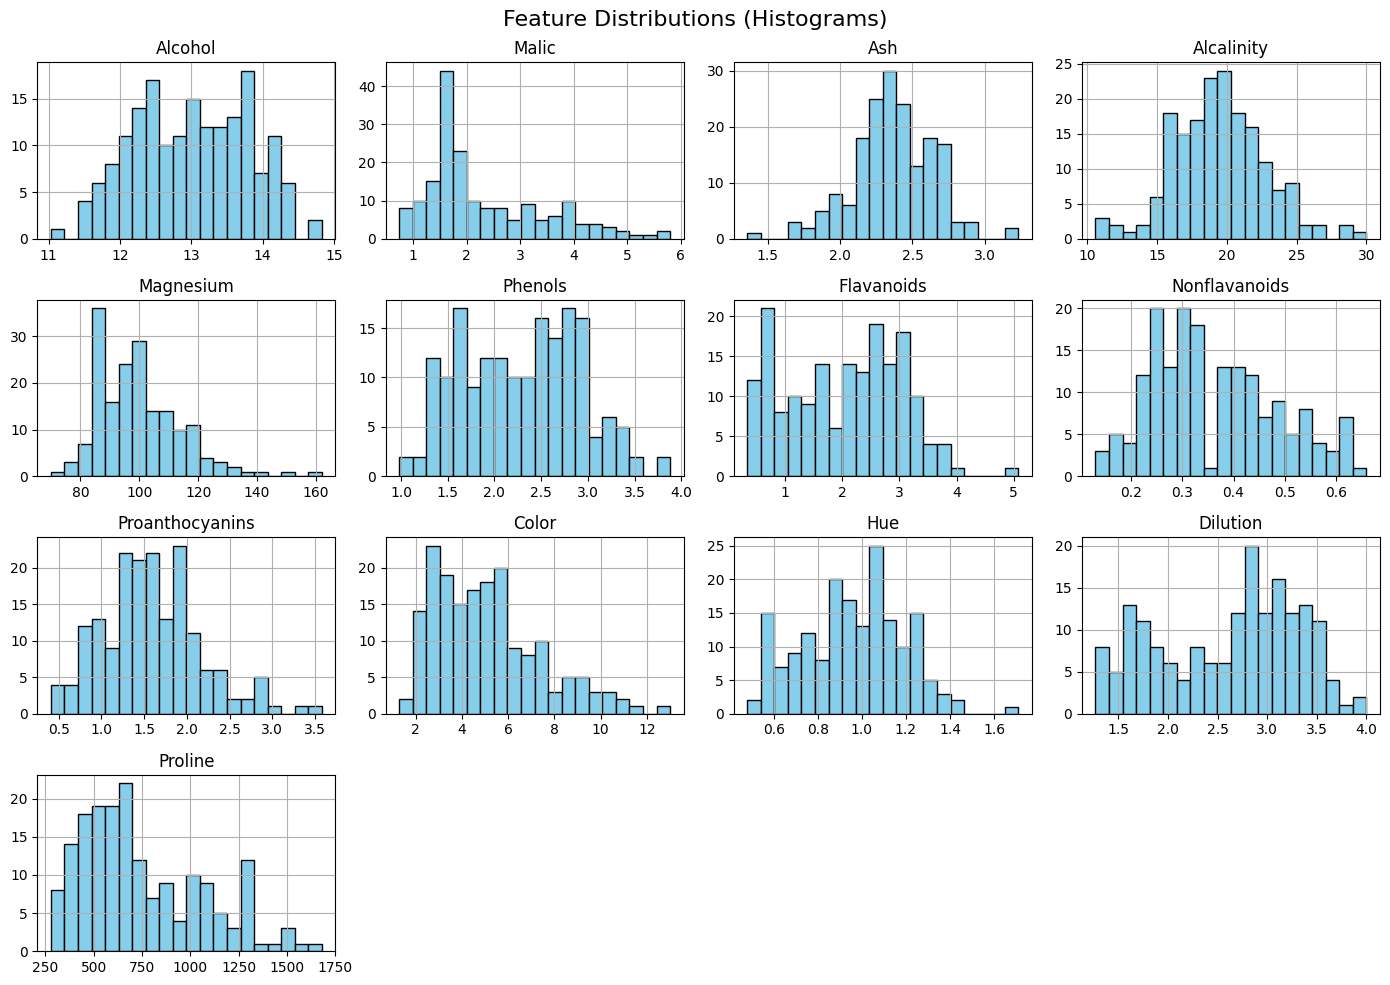

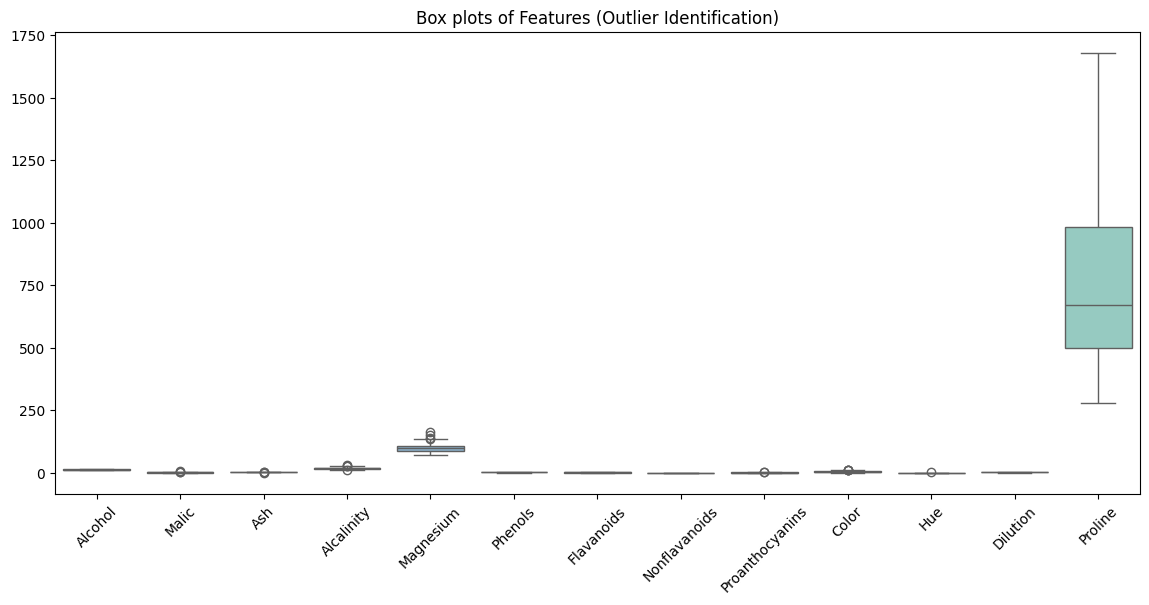

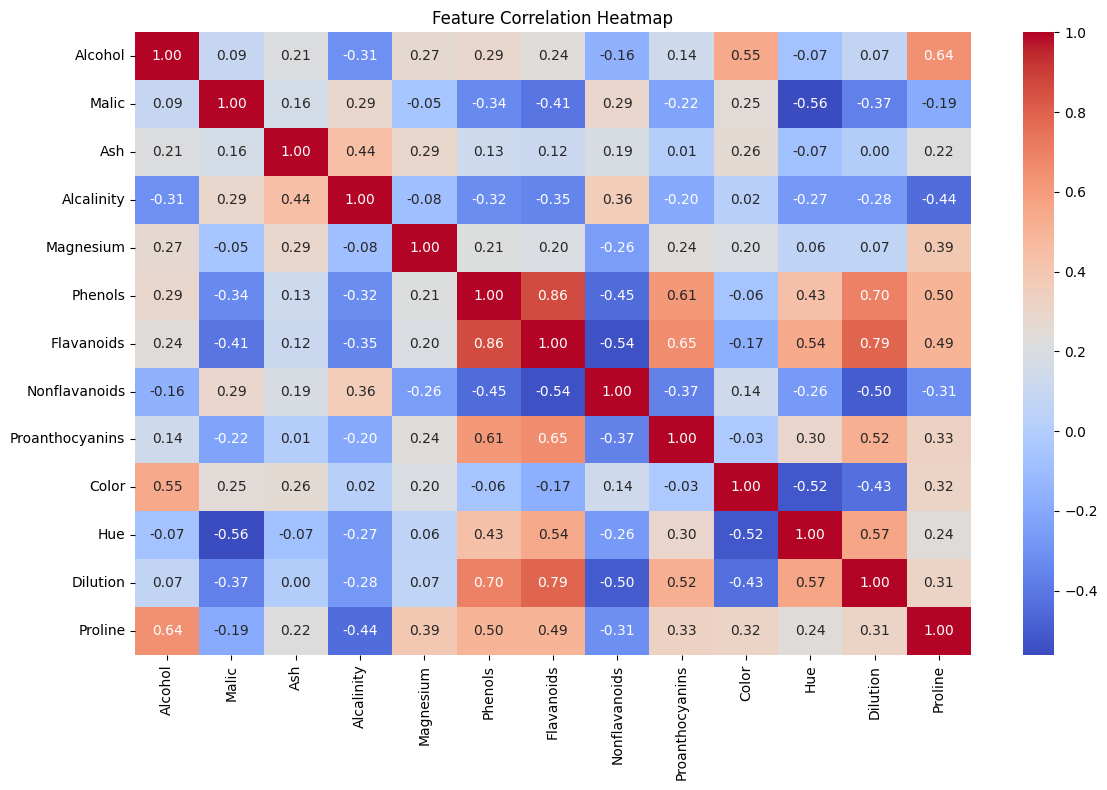

In [7]:
# Load dataset
df = pd.read_csv("/content/wine.csv")

print("--- Dataset Information ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

# Check missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Feature Distributions (Histograms)
X_features = df.drop(columns=["Type"])
X_features.hist(
    figsize=(14, 10), bins=20, color="skyblue", edgecolor="black"
)
plt.suptitle("Feature Distributions (Histograms)", fontsize=16)
plt.tight_layout()
plt.show()

# Box plots to identify outliers
plt.figure(figsize=(14, 6))
sns.boxplot(data=X_features, palette="Set3")
plt.title("Box plots of Features (Outlier Identification)")
plt.xticks(rotation=45)
plt.show()

# Correlation Matrix Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(X_features.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

**Task 2: Dimensionality Reduction with PCA**

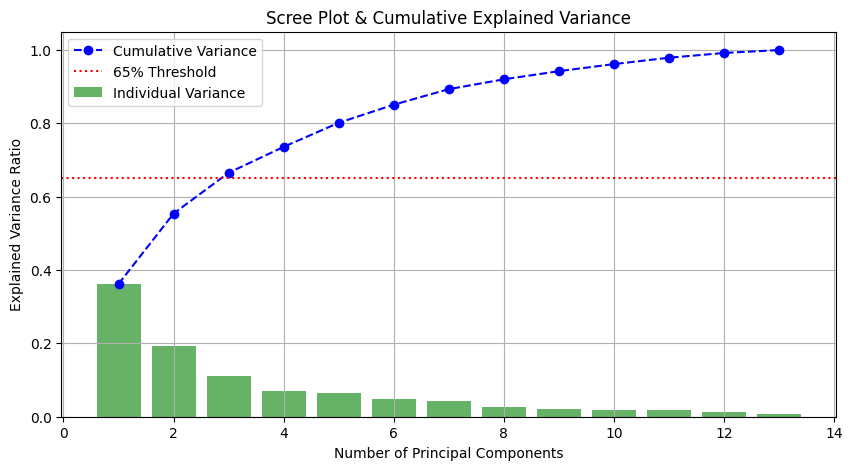


Cumulative Variance Explained by top 3 PCs: 0.6653


In [8]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Apply PCA
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance_ratio)

# Scree Plot & Cumulative Explained Variance Plot
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    cum_explained_variance,
    marker="o",
    linestyle="--",
    color="b",
    label="Cumulative Variance",
)
plt.bar(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    alpha=0.6,
    color="g",
    label="Individual Variance",
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot & Cumulative Explained Variance")
plt.axhline(y=0.65, color="r", linestyle=":", label="65% Threshold")
plt.legend()
plt.grid(True)
plt.show()

# Transform original dataset into top 3 Principal Components
pca_3 = PCA(n_components=3, random_state=42)
X_pca_3 = pca_3.fit_transform(X_scaled)

print(
    f"\nCumulative Variance Explained by top 3 PCs: {np.sum(pca_3.explained_variance_ratio_):.4f}"
)

**Task 3: Clustering with Original Data**


--- Clustering Performance on Original Data ---
Silhouette Score    : 0.2849
Davies-Bouldin Index: 1.3892


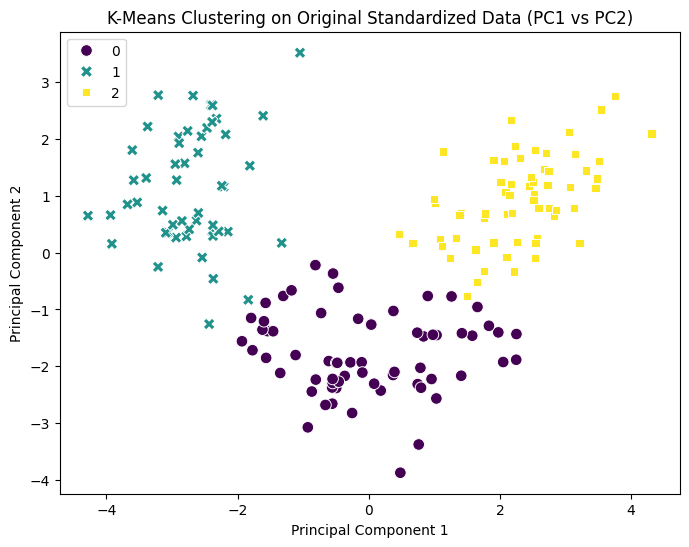

In [9]:
# Apply K-Means on original standardized data (K=3)
kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(X_scaled)

# Clustering metrics for original data
sil_orig = silhouette_score(X_scaled, labels_orig)
db_orig = davies_bouldin_score(X_scaled, labels_orig)

print("\n--- Clustering Performance on Original Data ---")
print(f"Silhouette Score    : {sil_orig:.4f}")
print(f"Davies-Bouldin Index: {db_orig:.4f}")

# Visualize Original Data Clusters (Projected on PC1 vs PC2)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca_3[:, 0],
    y=X_pca_3[:, 1],
    hue=labels_orig,
    palette="viridis",
    style=labels_orig,
    s=70,
)
plt.title("K-Means Clustering on Original Standardized Data (PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

**Task 4: Clustering with PCA Data**


--- Clustering Performance on PCA-Transformed Data ---
Silhouette Score    : 0.4532
Davies-Bouldin Index: 0.8400


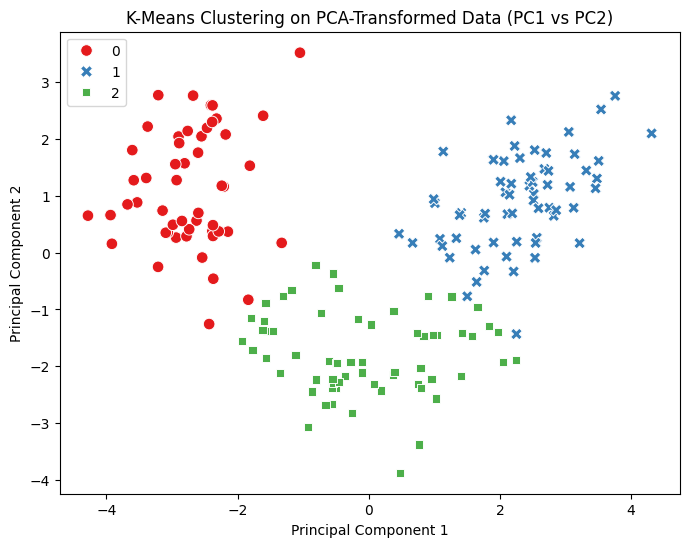

In [10]:
# Apply K-Means on PCA-transformed data (K=3)
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca_3)

# Clustering metrics for PCA data
sil_pca = silhouette_score(X_pca_3, labels_pca)
db_pca = davies_bouldin_score(X_pca_3, labels_pca)

print("\n--- Clustering Performance on PCA-Transformed Data ---")
print(f"Silhouette Score    : {sil_pca:.4f}")
print(f"Davies-Bouldin Index: {db_pca:.4f}")

# Visualize PCA Data Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca_3[:, 0],
    y=X_pca_3[:, 1],
    hue=labels_pca,
    palette="Set1",
    style=labels_pca,
    s=70,
)
plt.title("K-Means Clustering on PCA-Transformed Data (PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

**Task 5: Comparison and Analysis**

In [11]:
comparison_df = pd.DataFrame(
    [
        {
            "Dataset": "Original Standardized Features",
            "Silhouette Score (Higher is better)": sil_orig,
            "Davies-Bouldin Index (Lower is better)": db_orig,
        },
        {
            "Dataset": "PCA Transformed Features (3 PCs)",
            "Silhouette Score (Higher is better)": sil_pca,
            "Davies-Bouldin Index (Lower is better)": db_pca,
        },
    ]
)

print("\n--- Clustering Results Comparison ---")
print(comparison_df.to_string(index=False))


--- Clustering Results Comparison ---
                         Dataset  Silhouette Score (Higher is better)  Davies-Bouldin Index (Lower is better)
  Original Standardized Features                             0.284859                                1.389188
PCA Transformed Features (3 PCs)                             0.453235                                0.839971
